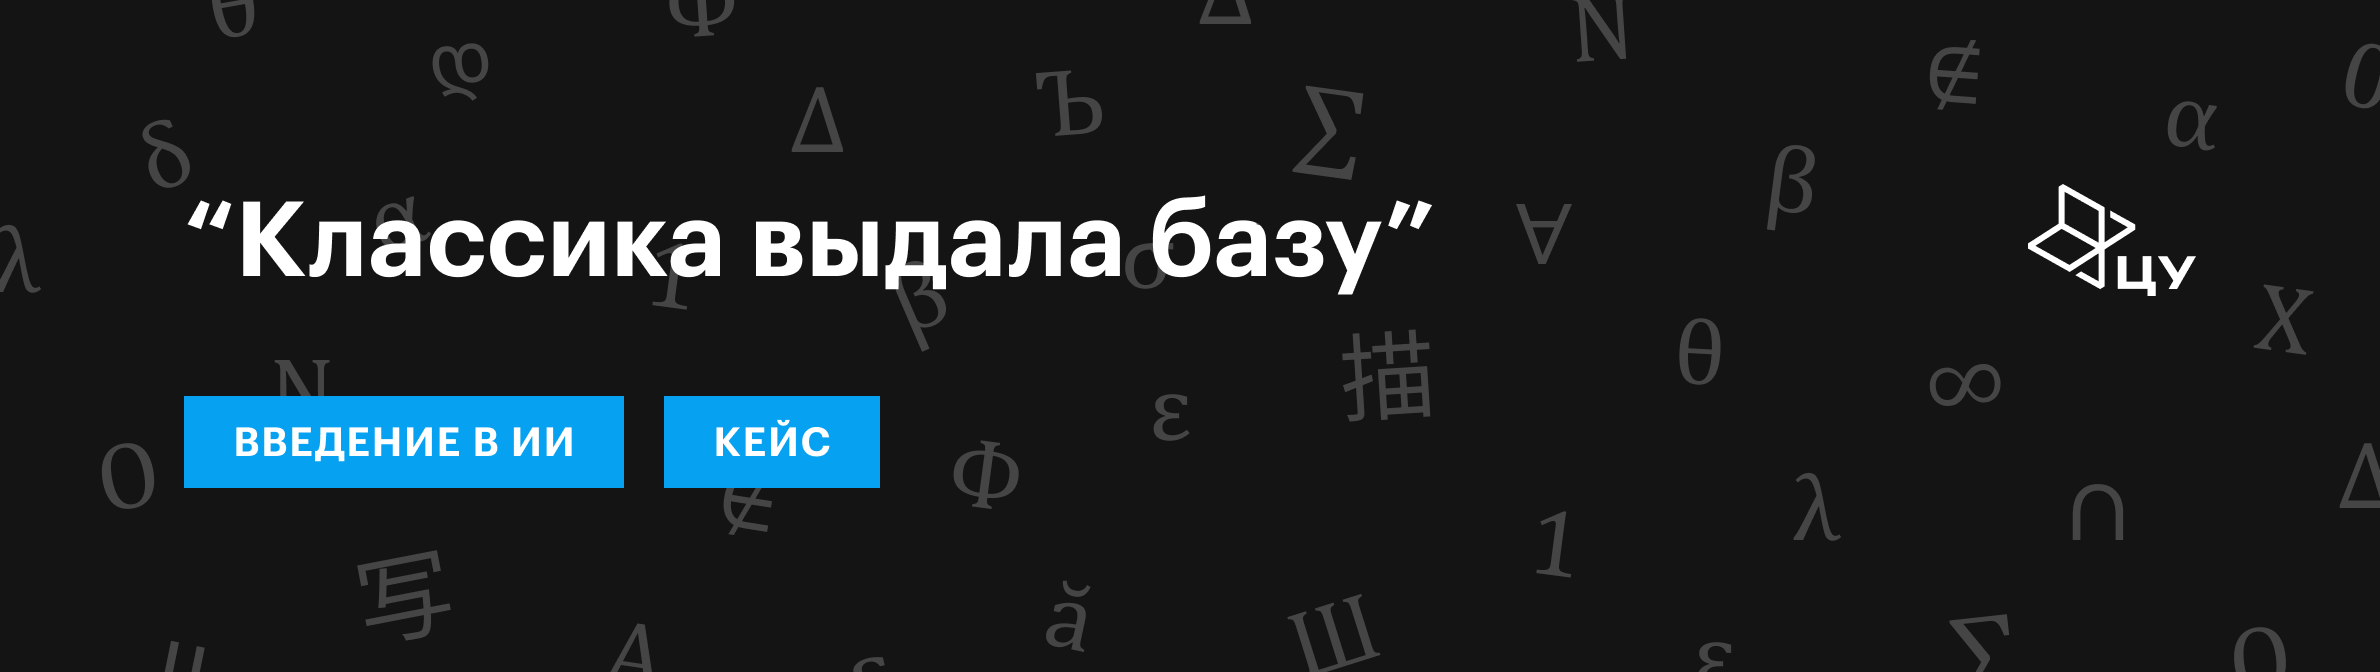

## Легенда

Представьте, что вы устроились NLP-инженером в образовательный EdTech-стартап. Маркетологи компании выяснили, что современные школьники тяжело воспринимают язык классической литературы XIX века.(Также в компанию наняли инженера, который смог встроить в каждую электронную книжкуу по экрану с Subway Surfers, чтобы ученикам было привычнее) Обилие устаревших слов, французских вставок и сложных деепричастных оборотов заставляет их «скипать» чтение.

Стартап решил запустить революционное приложение, которое будет «на лету» переводить тексты Толстого, Достоевского и Гоголя на современный интернет-сленг*.

Ваша задача: разработать нейросетевую Seq2Seq-модель, которая осуществляет перенос стиля (Text Style Transfer). Модель должна брать оригинальную реплику из классики и переписывать ее зумерским сленгом, максимально сохраняя смысл и изначальную структуру предложения.

*Примечение от автора кейса: данные по сленгу собирались из открытых источников: статей в интернете, рилсам, шортсам и тикитокам.*

## Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения:

* **Запрет на API-читерство:** Запрещено просто прогнать тестовый датасет через API умных ЛЛМок. Вы должны самостоятельно обучить модель. *При этом, если вам хочется использовать API LLM-сервисов для обогащения датасета, аугментаций и уточнения перевода, то это не запрещено.*

* **Ограничение по размеру модели:** Решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено

* **Воспроизводимость:** Весь код должен выполняться последовательно с первого раза. Обязательно фиксируйте random_seed, а также сохраняйте веса моделей и логируйте эксперимент.

**Необходимые этапы решения:**

1. Работа с датасетом. Посмотреть на статистику встречаемости слов и провести предобработку. Определиться с токенизатором и предложить простой бейзлайн.


2. Подбор архитектуры модели. Написание необходимых функций для работы с данной архитектурой. (Например, обрезка текста до 128 символов, для моделей с маленьким контекстным окном)


3. Обучение модели на датасете. Валидация метрик, подбор гиперпарметров генерации. Вспомогательные функции для генерации перевода для новых предложений (тут можно сделать функцию `def translate(text)`, которая занимается переводом текста)

**Проверяемые метрики:**

Оценка качества генерации текста — сложная задача. Мы будем использовать две метрики и смотреть на Loss модели:

*  Обучение (Train/Val Loss): Cross-Entropy Loss. Функция потерь, по которой модель обновляет веса. Желательно избежать переобучения и достичь результатов по Loss меньше ~1.5-2.0

* Главная бизнес-метрика: chrF (Character n-gram F-score). Оценивает совпадение сгенерированного текста с эталоном на уровне символов. Она идеально подходит для сленга, так как прощает ошибки в окончаниях (например, если модель выдала «кринж» вместо «кринжово»).

*  Вспомогательная метрика: BLEU-score. Классическая метрика машинного перевода. Посчитайте её для сравнения с chrF. Данная метрика легко считается и является бейзлайн-метрикой для любой задачи перевода.





## Система оценивания

Решение оценивается по трём параметрам
* **Работа с данными [4 балла]:** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными — визуализации, предобработка и очистка/обогащение датасета будут плюсом

* **Решение задачи [4 балла]:** Оценка ставится не за итоговые метрики — для простых моделей их значение может быть небольшим, а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, это решение будет оценено в полный балл

* **Оформление [2 балла]:** Хочется, чтобы написанный код читался, как хорошая книга. Для этого мы добавляем баллы за оформление — они выше, если в коде появляются визуализации, комментарии к коду и сопроводительный текст, и ниже за их отсутствие

## Данные

Итоговый датасет содержит 2 колонки: chunk и translate. В столбце chunk находится кусочек текста из классики. А в столбце translate – соответствующий ему перевод.


В данном датасете вы можете найти отрывки из следующих книг / сборников / произведений:

* А. П. Чехов — Собрание сочинений (рассказы и пьесы)

* А. С. Пушкин — повесть «Пиковая дама»

* И. С. Тургенев — роман «Отцы и дети»

* М. Ю. Лермонтов — роман «Герой нашего времени»

* Н. В. Гоголь — комедия «Ревизор»

* Н. В. Гоголь — поэма «Мёртвые души»

* А. Н. Островский — Собрание пьес (включая драму «Гроза»)

* Л. Н. Толстой — роман-эпопея «Война и мир»

* Ф. М. Достоевский — роман «Братья Карамазовы»



Для подбора метода, желательно подробно исследовать датасет – можно начать с простого просмотра перевода, а закончить построение векторных представлений слов. *Главное помните, EDA должен привести вас к пониманию решения проблемы*

Ссылка на датасет: https://drive.google.com/file/d/1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7/view

## Пояснение метрик



**BLEU-score** (Bilingual Evaluation Understudy)
Метрика основана на совпадении целых слов (униграмм) и их комбинаций (n-грамм: биграмм, триграмм и т.д.). Итоговый BLEU считается как геометрическое среднее точностей n-грамм, умноженное на штраф за краткость.

Формула:
$BLEU = BP \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$

Где:

$p_n$ — точность совпадения n-грамм (доля n-грамм из генерации, которые нашлись в эталоне).

$w_n$ — вес для $n$-граммы (обычно берут равномерные веса, например, для BLEU-4: $w_n = 0.25$).

$N$ — максимальная длина n-граммы (стандарт — 4).

$BP$ (Brevity Penalty) — штраф за краткость. Запрещает модели читерить, выдавая по одному правильному слову.

Формула штрафа за краткость ($BP$):
BP = \begin{cases} 1, & \text{если } c > r \\ \exp\left(1 - \frac{r}{c}\right), & \text{если } c \le r \end{cases}
Где $c$ — длина сгенерированного текста (candidate), $r$ — длина эталона (reference).



**chrF** (Character n-gram F-score)
В отличие от BLEU, chrF разбивает текст не на слова, а на символьные подстроки (от 1 до 6 символов) и считает по ним классическую F-меру.

Сначала считаются Precision и Recall для совпавших символьных кусочков:

$Precision (P) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в генерации}}$


$Recall (R) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в эталоне}}$

Затем вычисляется итоговая формула chrF (это стандартная $F_\beta$-мера):

$chrF = (1 + \beta^2) \frac{P \cdot R}{\beta^2 \cdot P + R}$

Где:

$\beta$ — параметр, определяющий баланс между точностью и полнотой.

В стандартной реализации (chrF2) используют $\beta = 2$, что дает больший вес Recall (полноте) — то есть алгоритму важнее, чтобы модель не потеряла смысл оригинала, даже если она добавила от себя лишние символы.

### Пример работы метрик

**Оригинал:** "Это было ужасно"

**Эталон**: "это было кринжово"

**Сгенерировано моделью:** "это был кринж"

----



BLEU разбивает текст по пробелам:

Слова эталона: ["это", "было", "кринжово"]

Слова модели: ["это", "был", "кринж"]

Для BLEU слова "было" и "был", а также "кринжово" и "кринж" — это абсолютно разные, никак не связанные слова (как "собака" и "самолет"). Совпало только одно слово: "это".


Шаг 1: Считаем совпадения (Precision для n-грамм)

1-граммы (отдельные слова): Из 3 сгенерированных слов в эталоне есть только одно — "это". $p_1 = 1 / 3 \approx 0.33$ (33%).

2-граммы (пары слов):
Пары модели: ["это был", "был кринж"].
Пары эталона: ["это было", "было кринжово"].
Совпадений нет! Точность $p_2 = 0 / 2 = 0$.

Шаг 2: Штраф за краткость (Brevity Penalty)
Длина генерации ($c=3$) равна длине эталона ($r=3$), поэтому модель не штрафуется за обрывание текста. $BP = 1$

Шаг 3: Итоговая формула BLEU

$$BLEU = BP \cdot \exp\left( \frac{1}{2} \log p_1 + \frac{1}{2} \log p_2 \right)$$

Так как точность биграмм $p_2 = 0$, логарифм нуля уходит в минус бесконечность, и весь BLEU обнуляется.

$$BLEU = 0$$

- - -

chrF нарезает текст на куски (например, по 4 символа, включая пробелы):

Куски эталона (14 штук):
"это_", "то_б", "о_бы", "_был", "было", "ыло_", "ло_к", "о_кр", "_кри", "крин", "ринж", "инжо", "нжов", "жово"

Куски модели (10 штук):
"это_", "то_б", "о_бы", "_был", "был_", "ыл_к", "л_кр", "_кри", "крин", "ринж"

Шаг 1: Ищем совпадения
Алгоритм сравнивает два списка и находит 7 идеальных совпадений:
"это_", "то_б", "о_бы", "_был", "_кри", "крин", "ринж". Корень слова и начало предложения схвачены верно!

Алгоритм видит, что куски "это ", "то б", " был", " кри", "крин", "ринж" совпали


Шаг 2: Считаем Точность (Precision) и Полноту (Recall)

Precision ($P$): Доля правильных кусков среди всех сгенерированных.
$P = 7 / 10 = 0.70$ (70% того, что выдала модель — верно).

Recall ($R$): Доля кусков эталона, которые смогла покрыть модель.
$R = 7 / 14 = 0.50$ (Модель восстановила 50% от оригинальной строки).

Шаг 3: Итоговая формула (F2-score)
chrF по умолчанию использует $\beta = 2$, что дает Полноте в 2 раза больший вес, чем Точности (важнее не потерять смысл, чем не наделать опечаток).

$$chrF = 5 \frac{P \cdot R}{4p+R}$$

Подставляем наши числа и получаем ответ:

$$chrF = 5 \frac{0.7 \cdot 0.5}{4\cdot 0.7 + 0.5} \approx 0.53$$

### Код метрик

Ниже уже реализованы функции подсчёта метрик. Тебе необходимо лишь использовать их

In [1]:
import math
from collections import Counter

def get_word_ngrams(tokens: list, n: int) -> list:
    """
    Разбивает список токенов на n-граммы уровня слов.
    """
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


def get_char_ngrams(text: str, n: int) -> list:
    """
    Разбивает строку на n-граммы уровня символов.
    """
    return [text[i : i + n] for i in range(len(text) - n + 1)]


Покажем как работает базовое разбиение на n-граммы: посимвольные и по-"подсловные".

In [2]:
get_word_ngrams(["я", "тебя", "крашу", "чееел"], 2)

[('я', 'тебя'), ('тебя', 'крашу'), ('крашу', 'чееел')]

In [3]:
get_char_ngrams("кринж", 3)

['кри', 'рин', 'инж']

Вычислим теперь наши метрики для двух наших текстов

In [4]:
def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    Вычисляет BLEU-score для одной пары (reference, candidate).
    Шаги:
      1. Токенизация — разбиение по пробелам
      2. Clipped precision — для каждого n считаем долю n-грамм генерации,
         которые есть в эталоне; одна n-грамма эталона не засчитывается дважды
      3. Add-1 сглаживание — (matches + 1) / (total + 1), чтобы избежать log(0)
         при нулевых совпадениях в высших n-граммах
      4. Brevity Penalty — штраф exp(1 - r/c), если генерация короче эталона

    Args:
        reference : эталонный текст (строка)
        candidate : сгенерированный текст (строка)
        max_n     : максимальный порядок n-граммы (по умолчанию 4 → BLEU-4)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    ref_tokens  = reference.lower().split()
    cand_tokens = candidate.lower().split()

    c = len(cand_tokens)
    r = len(ref_tokens)

    if c == 0:
        return 0.0

    # Штрафуем только за генерацию короче эталона; длиннее — штрафа нет
    bp  = 1.0 if c > r else math.exp(1 - r / c)
    w_n = 1.0 / max_n
    log_avg = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_word_ngrams(ref_tokens, n))
        cand_ngrams = Counter(get_word_ngrams(cand_tokens, n))

        # Clipped: не даём модели накручивать счёт повторами одной n-граммы
        matches = sum(min(cnt, ref_ngrams[ngram]) for ngram, cnt in cand_ngrams.items())
        total   = max(c - n + 1, 1)  # floor=1, если предложение короче n

        # Нет совпадений даже на уровне слов — тексты семантически разные
        if n == 1 and matches == 0:
            return 0.0

        p_n      = (matches + 1) / (total + 1)
        log_avg += w_n * math.log(p_n)

    return bp * math.exp(log_avg)


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Вычисляет chrF-score для одной пары (reference, candidate).

    Шаги:
      1. Разбить оба текста на символьные n-граммы (для n от 1 до max_n)
      2. Для каждого n посчитать Precision и Recall по совпавшим кускам
      3. Усреднить Precision и Recall по всем n
      4. Итог: F_beta-мера из усредненных P и R

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок символьной n-граммы (по умолчанию 6)
        beta       : вес Recall относительно Precision (по умолчанию 2.0 -> chrF2)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    if len(candidate) == 0 or len(reference) == 0:
        return 0.0

    total_precision = 0.0
    total_recall    = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_char_ngrams(reference, n))
        cand_ngrams = Counter(get_char_ngrams(candidate, n))

        # Считаем совпавшие символьные куски
        matches = sum(
            min(count, ref_ngrams.get(ngram, 0))
            for ngram, count in cand_ngrams.items()
        )

        total_cand = sum(cand_ngrams.values())  # знаменатель Precision
        total_ref  = sum(ref_ngrams.values())   # знаменатель Recall

        if total_cand > 0:
            total_precision += (matches + 1)/ (total_cand + 1)
        if total_ref > 0:
            total_recall += matches / total_ref

    # Усредняем Precision и Recall по всем порядкам n
    avg_p = total_precision / max_n
    avg_r = total_recall    / max_n

    if avg_p + avg_r == 0:
        return 0.0

    # считаем f-бета меру
    chrf = (1 + beta**2) * (avg_p * avg_r) / (beta**2 * avg_p + avg_r)
    return chrf




А теперь с помощью функций выше напишем вычисление метрик для массива текстов. Мы используем такой же интерфейс как у `sci-kit-learn`, где есть необходимо передать `y_true` и `y_pred`

In [5]:
def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """Считает средний BLEU по всем парам датасета."""
    scores = [bleu_single(ref, cand, max_n) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """Считает средний chrF по всем парам датасета."""
    scores = [chrf_single(ref, cand, max_n, beta) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


А здесь мы посмотрим на примеры работы этих метрик с помощью assert-ов

In [6]:

# ──────────────── ТЕСТ 1 ────────────────
# Идеальное совпадение: предсказание == эталон
# Ожидание: BLEU = 1.0, chrF = 1.0
ref = "этот анк выдал жесткую базу"
assert bleu_single(ref, ref) == 1.0, \
    "ТЕСТ 1 BLEU: При идеальном совпадении BLEU должен быть 1.0"
assert abs(chrf_single(ref, ref) - 1.0) < 1e-9, \
    " ТЕСТ 1 chrF: При идеальном совпадении chrF должен быть 1.0"
print("Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0")

# ──────────────── ТЕСТ 2 ────────────────
# Пустая генерация: candidate = ""
# Ожидание: BLEU = 0.0, chrF = 0.0
ref = "он буквально вкрашился в неё"
assert bleu_single(ref, "") == 0.0, \
    " ТЕСТ 2 BLEU: Пустая генерация должна давать 0.0"
assert chrf_single(ref, "") == 0.0, \
    " ТЕСТ 2 chrF: Пустая генерация должна давать 0.0"
print("Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0")

# ──────────────── ТЕСТ 3 ────────────────
# Полностью разные тексты
# Ожидание: BLEU = 0.0, chrF близко к 0
ref  = "служить бы рад прислуживаться тошно"
cand = "икс игрек зет фу бар"
assert bleu_single(ref, cand) == 0.0, \
    " ТЕСТ 3 BLEU: Полностью разные тексты → BLEU должен быть 0.0"
assert chrf_single(ref, cand) < 0.1, \
    " ТЕСТ 3 chrF: Полностью разные тексты → chrF должен быть близок к 0"
print(" Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0")

# ──────────────── ТЕСТ 4 ────────────────
# Ключевой тест: chrF > BLEU при морфологическом совпадении
# "кринж" vs "кринжово" — разные слова для BLEU, но похожие символьно для chrF
ref  = "это было кринжово"
cand = "это было кринж"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert chrf_score > bleu_score, \
    f" ТЕСТ 4: chrF ({chrf_score:.3f}) должен быть > BLEU ({bleu_score:.3f}) при морфологических различиях!"
print(f" Тест 4 пройден: chrF ({chrf_score:.3f}) > BLEU ({bleu_score:.3f}) — chrF лучше для русской морфологии!")

# ──────────────── ТЕСТ 5 ────────────────
# Частичное совпадение: значения должны быть строго в диапазоне (0, 1)
ref  = "базаров выдал жесткую базу и ливнул"
cand = "базаров выдал базу и просто ушел"
bleu_score = bleu_single(ref, cand)
chrf_score = chrf_single(ref, cand)
assert 0.0 < bleu_score < 1.0, \
    f" ТЕСТ 5 BLEU: При частичном совпадении BLEU должен быть в (0, 1), получили {bleu_score:.3f}"
assert 0.0 < chrf_score < 1.0, \
    f" ТЕСТ 5 chrF: При частичном совпадении chrF должен быть в (0, 1), получили {chrf_score:.3f}"
print(f" Тест 5 пройден: Частичное совпадение → BLEU={bleu_score:.3f}, chrF={chrf_score:.3f}")

# ──────────────── ТЕСТ 6 ────────────────
# Тест усреднения по датасету
y_true = ["этот скуф выдал базу",     "она ливнула с вписки"]
y_pred = ["этот скуф выдал базу",     "она ливнула с вписки"]  # идеальные предсказания
assert compute_bleu(y_true, y_pred) == 1.0, \
    " ТЕСТ 6 BLEU: Усредненный BLEU по идеальным парам должен быть 1.0"
assert abs(compute_chrf(y_true, y_pred) - 1.0) < 1e-9, \
    " ТЕСТ 6 chrF: Усредненный chrF по идеальным парам должен быть 1.0"
print(" Тест 6 пройден: Усреднение по датасету работает корректно!")


Тест 1 пройден: Идеальное совпадение → BLEU=1.0, chrF=1.0
Тест 2 пройден: Пустая генерация → BLEU=0.0, chrF=0.0
 Тест 3 пройден: Полностью разные тексты → BLEU=0.0, chrF≈0
 Тест 4 пройден: chrF (0.825) > BLEU (0.595) — chrF лучше для русской морфологии!
 Тест 5 пройден: Частичное совпадение → BLEU=0.366, chrF=0.560
 Тест 6 пройден: Усреднение по датасету работает корректно!


## Твой код

In [7]:
!gdown 1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7

Downloading...
From: https://drive.google.com/uc?id=1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7
To: /content/dataset.csv
100% 31.9M/31.9M [00:00<00:00, 90.7MB/s]


In [8]:
import re
import pandas as pd


In [9]:
df = pd.read_csv("/content/dataset.csv")

In [10]:

to_clean = list("thoughtful predictions florensia <thought>".split())

shit = [
    r'openrouter',
    r'\berror\b',
    r'не превратить .*? в пародию',
    r'\b16\s*[-–—]\s*18\s*лет\b',
]

shit_regex = re.compile("|".join(shit), flags=re.IGNORECASE)

def clean_text(text):
    text = str(text)
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r'[–—]', '-', text)
    text = re.sub(r'^\s*\d{5,}(?=\s|[-.,:;!?])\s*', '', text)
    text = re.sub(r'^\s*(thought|response|error|key)\s*[:\-]?\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'сленг должен быть умеренным,\s*чтобы не превратить [^.]+? в пародию', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'[^\w\s.,!?;:\-]', ' ', text, flags=re.UNICODE)
    words = text.split()
    words = [w for w in words if w.lower() not in to_clean]
    text = ' '.join(words)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clear_df(df):
    df = df[["chunk", "translate"]].dropna().copy()

    df['chunk'] = df['chunk'].astype(str)
    df['translate'] = df['translate'].astype(str)

    bad = df["chunk"].str.contains(shit_regex, na=False) | df["translate"].str.contains(shit_regex, na=False)
    df = df[~bad].copy()

    df["chunk"] = df["chunk"].apply(clean_text)
    df["translate"] = df["translate"].apply(clean_text)

    bad = df["chunk"].str.contains(shit_regex, na=False) | df["translate"].str.contains(shit_regex, na=False)
    df = df[~bad].copy()

    df = df.reset_index(drop=True)
    return df

In [11]:
df = clear_df(df)

In [12]:
df.to_csv('output.csv')

In [13]:
df.sample(20)

,chunk,translate
1152,"оглядываясь и поникнув головой. Ему казалось, ...","оглядываясь и поникнув головой. ему казалось, ..."
431,"Хлестаков. Сделайте милость, садитесь. Я тепер...","хлестаков. да ладно, сделайте одолжение, призе..."
606,"ему очень к лицу. И как я гнусен, подл и презр...","ему очень к лицу. и как я гнусен, подл и презр..."
211,- А! так это вас ударил я так неловко по голов...,- о! так это по твоей голове я так неловко при...
687,"в кабак. Тут выпьет, махнет рукой и, не заплат...","в бар. тут выпьет, махнет рукой и, не задонати..."
3561,Все было в порядке необыкновенном. Леса были з...,Все было в порядке необыкновенном. Леса были з...
2832,"- Чего шепчу? Ах, черт возьми, - крикнул вдруг...","- Чего шепчу? Ах, черт возьми, - крикнул вдруг..."
1579,"слову для того, чтобы показать обедающим, что ...","слову для того, чтобы показать обедающим, что ..."
1054,"Он страдал, возмущался и даже стыдился. Ему ст...","он страдал, возмущался и даже ловил кринж. ему..."
2666,"Дядюшка, ни на кого не глядя, сдунул пыль, кос...","Дядюшка, ни на кого не глядя, сдунул пыль, кос..."


In [14]:
!pip install transformers datasets sentencepiece evaluate -q

In [15]:
import torch

In [16]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "ai-forever/ruT5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [17]:
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, str(a), str(b)).ratio()

def jaccard(a: str, b: str) -> float:
    a_set = set(str(a).lower().split())
    b_set = set(str(b).lower().split())
    if not a_set or not b_set:
        return 0.0
    return len(a_set & b_set) / max(len(a_set | b_set), 1)

df['sim_ratio'] = df.apply(lambda row: similarity(row['chunk'], row['translate']), axis=1)
df['jaccard'] = df.apply(lambda row: jaccard(row['chunk'], row['translate']), axis=1)

print(df[['sim_ratio', 'jaccard']].describe())


         sim_ratio      jaccard
count  3605.000000  3605.000000
mean      0.472840     0.754647
std       0.323357     0.239639
min       0.000590     0.000000
25%       0.179405     0.741697
50%       0.448058     0.837838
75%       0.759746     0.909341
max       1.000000     1.000000


In [18]:
print(df["sim_ratio"].describe())

count    3605.000000
mean        0.472840
std         0.323357
min         0.000590
25%         0.179405
50%         0.448058
75%         0.759746
max         1.000000
Name: sim_ratio, dtype: float64


In [19]:
print(df["jaccard"].describe())

count    3605.000000
mean        0.754647
std         0.239639
min         0.000000
25%         0.741697
50%         0.837838
75%         0.909341
max         1.000000
Name: jaccard, dtype: float64


In [20]:
df = df[(df['sim_ratio'] < 0.78) & (df['jaccard'] < 0.72)].copy()
print('after filter:', len(df))

after filter: 794


In [21]:
df["chunk_len"] = df["chunk"].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=False))
)

df["translate_len"] = df["translate"].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=False))
)
quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

stats = pd.DataFrame({
    'chunk': df['chunk_len'].quantile(quantiles),
    'translate': df['translate_len'].quantile(quantiles)
})

print(stats)

        chunk  translate
0.01    18.86      20.86
0.05   159.30     151.55
0.10   209.60     214.90
0.25   284.00     291.00
0.50   422.50     454.50
0.75   617.75     563.00
0.90   871.00     839.10
0.95   941.35     970.35
0.99  1110.61    1063.35


In [22]:
from datasets import Dataset

dataset = Dataset.from_pandas(df[["chunk", "translate"]])

max_input_length = 256
max_target_length = 192

prompt = 'перефразируй текст на современный русский сленг, сохрани смысл, но не копируй исходные формулировки: '

def preprocess_function(dataset):
    inputs = [
        prompt + text
        for text in dataset["chunk"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        dataset["translate"],
        max_length=max_target_length,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/794 [00:00<?, ? examples/s]

In [23]:
split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

In [24]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, EarlyStoppingCallback

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    pad_to_multiple_of=8,
)

training_args = Seq2SeqTrainingArguments(
    output_dir='./rut5_slang_model',
    do_train=True,
    do_eval=True,

    per_device_train_batch_size=6,
    per_device_eval_batch_size=6,
    gradient_accumulation_steps=4,

    num_train_epochs=8,
    learning_rate=3e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,

    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=50,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,

    fp16=torch.cuda.is_available(),
    predict_with_generate=False,
    report_to='none',
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [25]:
print(len(train_dataset))

714


In [26]:
trainer = Seq2SeqTrainer(
    model=model,

    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## Итог



In [28]:
def translate(old_text):
    kanye = prompt + old_text
    inputs = tokenizer(kanye, return_tensors="pt", truncation=True, max_length=256).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            num_beams=4
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return result.strip()

In [29]:
from torch.utils.data import DataLoader
from tqdm import tqdm


  0%|          | 0/3 [02:09<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Пример изначального текста и его переведённая версия
example = '''Я вас любил: любовь еще, быть может,
В душе моей угасла не совсем'''

translated_example = translate(example)

print(f"Кросс-энтропия: {cross_entropy_loss}\nChr-F: {chr_f_metric}\nBLEU: {bleu_metric}\n\nПеревод: {translated_example}")